In [ ]:
# 40 years of boxplots
# Hadley Wickham and Lisa Stryjewski
# 2011
# https://vita.had.co.nz/papers/boxplots.pdf

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# import seaborn as sns  # doesn't do weighted; OOMs on expand

In [2]:
plt.style.use('seaborn-v0_8')

In [3]:
data = pd.read_csv('smaller.csv', dtype={'SOCP': str})
data['inc2024'] = data.PINCP * data.ADJINC / 1_000_000
print(data.shape, data.PWGTP.sum())

data = data.dropna(subset=['PWGTP', 'ADJINC', 'PINCP'])
print(data.shape, data.PWGTP.sum())

data = data[data.inc2024 > 0]
print(data.shape, data.PWGTP.sum())

(3422888, 7) 340110990
(2912790, 7) 280613270
(2556439, 7) 245168158


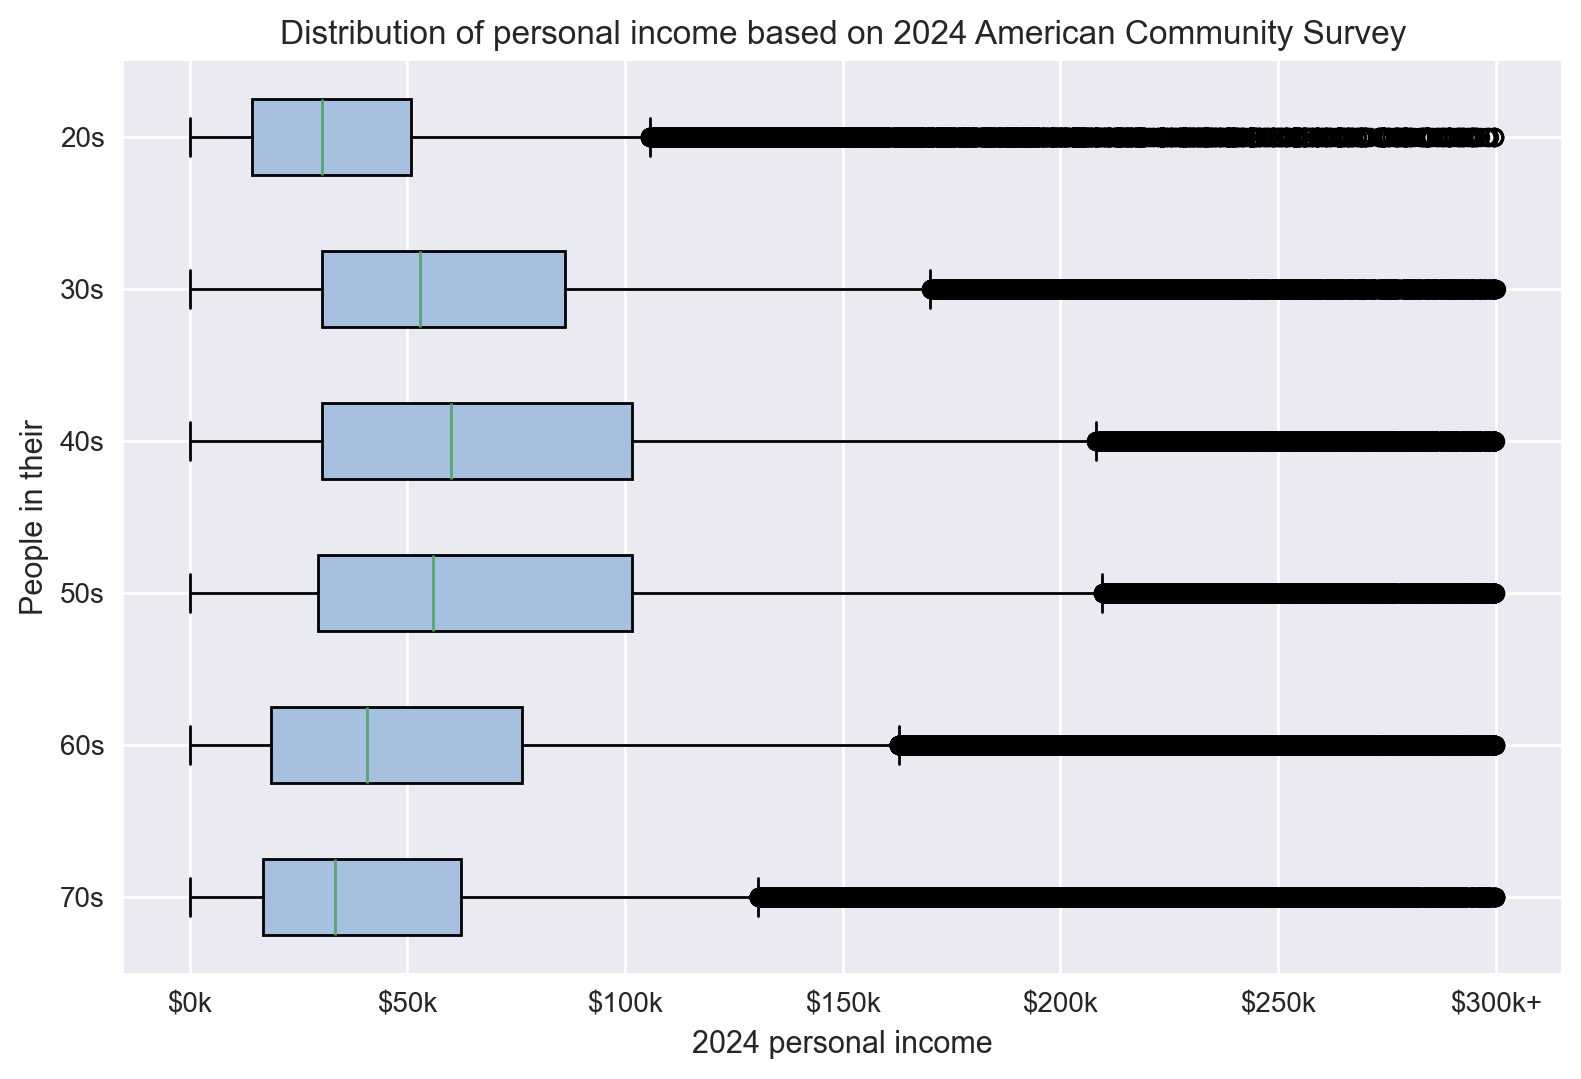

In [19]:
#bins = range(0, 310_000, 10_000)

def fmtx(x, _):
    label = f'${int(x/1000)}k'
    if x == 300000:
        label += '+'
    return label

def weighted_quantile(values, weights, quantiles):  # Claude
    sorter = np.argsort(values)
    v, w = values[sorter], weights[sorter]
    cumw = np.cumsum(w) - 0.5 * w
    cumw /= cumw[-1]
    return np.interp(quantiles, cumw, v)

stats = []

for index in range(6):
#for cat, grp in df.groupby('category'):
    group = data.AGEP // 10 == (index + 2)
    v, w = data.inc2024[group].values, data.PWGTP[group].values
    q1, med, q3 = weighted_quantile(v, w, [0.25, 0.5, 0.75])
    iqr = q3 - q1
    fliers = data.inc2024[group & ((q3 + 1.5*iqr) < data.inc2024) & (data.inc2024 <= 300_000)]
    stats.append({
        'med': med, 'q1': q1, 'q3': q3,
        'whislo': max(q1 - 1.5*iqr, 1), 'whishi': q3 + 1.5*iqr,
        'label': f'{index + 2}0s',
        'fliers': fliers
    })

fig, ax = plt.subplots()
ax.bxp(stats[::-1], showfliers=True, vert=False, patch_artist=True, boxprops={'facecolor': '#A8C0DF'})
lower, _ = plt.xlim()
plt.xlim(right=300_000 - lower)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmtx))
plt.ylabel('People in their')
plt.xlabel('2024 personal income')
plt.title('Distribution of personal income based on 2024 American Community Survey')
plt.tight_layout()
plt.show()

In [ ]:
def fmtx(x, _):
    label = f'${int(x/1000)}k'
    if x == 300000:
        label += '+'
    return label

fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(10, 6), sharex=True, sharey=True)

for index, ax in enumerate(axes):
    group = data.AGEP // 10 == (index + 2)
    ax.hist(
        data.inc2024[group].clip(upper=300_000),
        weights=data.PWGTP[group],
        bins=bins,
        label=f'People in their {index + 2}0s')
    ax.legend(handlelength=0, handletextpad=0, prop={'size': 18, 'weight': 'bold'})

axes[-1].xaxis.set_major_formatter(mticker.FuncFormatter(fmtx))
plt.xlabel('2024 personal income')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
axes[0].set_title('Distribution of personal income based on 2024 American Community Survey')
plt.tight_layout()
plt.show()